(template)=

# Template: titel van de lecture

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 19XX–19YY.

**Wat we al weten.** Twee tot vier korte zinnen over wat de vorige lectures
hebben opgeleverd: de theorie, de data en de barst die het vorige tijdvak
achterliet. Verwijs naar hoogstens twee eerdere lectures, bijvoorbeeld
[](#template).

**Welke vraag staat open.** Eén scherp geformuleerde vraag. Deze lecture
beantwoordt die vraag, of een deel ervan.
```

## Overzicht

De eerste twee zinnen geven de vraag en het antwoord van deze lecture. Daarna
volgt een lijst van wat we doen, en pas dan de geschiedenis. Bijvoorbeeld:

Waarom kost een claim op onzekere toekomstige betalingen wat hij kost? Omdat een
euro meer waard is in slechte tijden dan in goede, en de prijs die weging
optelt. In deze lecture:

- leiden we de waarderingsvergelijking $p_t = \E_t[m_{t+1} x_{t+1}]$ af uit één
  eerste-ordevoorwaarde;
- laten we zien dat verwachte rendementen daaruit een bèta-vorm krijgen;
- simuleren we hoe vaak een activum zonder enige alpha toch significant lijkt;
- repliceren we tabel 3 van Lucas {cite}`Lucas1978` op French-data.

Lucas publiceerde het model in 1978 {cite}`Lucas1978`. Het definieert dit
tijdvak omdat het de discontovoet voor het eerst uit een optimalisatieprobleem
laat volgen. Deze alinea is de enige plek voor geschiedenis en citaties in het
Overzicht; de imports-cel staat niet hier maar bij het toy-voorbeeld.

## Intuïtie: waarom zou dit waar zijn?

Voordat er één symbool op papier komt: leg het mechanisme uit in gewone taal.
Een lezer die alleen deze sectie leest, moet het resultaat kunnen navertellen.
Korte zinnen, één beeld per alinea, geen u-vorm en geen je-vorm.

Een historische anekdote mag, mits die het argument dient. Dat Bachelier zijn
proefschrift bij Poincaré verdedigde en een matige beoordeling kreeg, is aardig.
Het wordt relevant zodra duidelijk is dat de wiskunde van 1900 nog geen taal had
voor wat hij deed.

```{note}
Een `{note}` is voor terzijdes die de lezer helpen maar niet nodig zijn voor de
hoofdlijn: een historische voetnoot, een alternatieve afleiding, een opmerking
over notatie. Met `:class: dropdown` blijft hij ingeklapt.
```

## Toy-voorbeeld: twee toestanden, drie activa

Het kleinste voorbeeld waarin het mechanisme al zichtbaar is, met getallen die op
papier na te rekenen zijn. Eerst met de hand, dan in code, en de code moet
dezelfde getallen geven. Het toy-voorbeeld mag hoogstens één formule gebruiken
die nog niet is afgeleid; hier is dat $p = \E[m x]$, en de theorie leidt die
formule als eerste af.

De imports-cel staat hier, aan het begin van de eerste sectie met code. Dit is
de enige imports-cel van de lecture.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

**Opzet.** Er zijn twee toestanden op $t+1$, "goed" en "slecht", elk met kans
$1/2$, en drie activa:

| Activum | payoff goed | payoff slecht | prijs $p$ |
|---|---|---|---|
| obligatie | 1{,}00 | 1{,}00 | 0{,}95 |
| aandeel   | 1{,}40 | 0{,}70 | 0{,}95 |
| put       | 0{,}00 | 0{,}30 | ?      |

**Het recept.** De prijs van elk activum is de kansgewogen som van zijn payoffs,
elk vermenigvuldigd met een gewicht $m$ dat van de toestand afhangt:
$p = \tfrac12 m_g x_g + \tfrac12 m_s x_s$. Dat gewicht is de stochastic discount
factor. Twee verhandelde activa geven twee vergelijkingen in twee onbekenden.

**Stap 1.** Uit de obligatie: $\tfrac12 m_g + \tfrac12 m_s = 0{,}95$, dus
$m_g + m_s = 1{,}90$.

**Stap 2.** Uit het aandeel: $0{,}70\,m_g + 0{,}35\,m_s = 0{,}95$. Vul
$m_s = 1{,}90 - m_g$ in: $0{,}35\,m_g = 0{,}285$, dus $m_g = 0{,}8143$ en
$m_s = 1{,}0857$.

**Stap 3.** De put volgt zonder verdere aannames:
$p_{\text{put}} = \tfrac12 \cdot 1{,}0857 \cdot 0{,}30 = 0{,}1629$. De risicovrije
rente is $R^f = 1/\E[m] = 1/0{,}95 = 1{,}0526$.

De SDF is hoog in de slechte toestand, zoals de intuïtie voorspelde: een euro is
meer waard voor wie arm is. Nu dezelfde getallen in code.

In [2]:
prob = np.array([0.5, 0.5])
payoffs = np.array([[1.00, 1.00],    # obligatie
                    [1.40, 0.70]])   # aandeel
prices = np.array([0.95, 0.95])

m = np.linalg.solve(payoffs * prob, prices)      # p = E[m x] als lineair stelsel
put = float((prob * m) @ np.array([0.00, 0.30]))
rf = 1 / (prob @ m)

hand = pd.Series({"m_goed": 0.8143, "m_slecht": 1.0857, "R^f": 1.0526, "put": 0.1629})
code = pd.Series({"m_goed": m[0], "m_slecht": m[1], "R^f": rf, "put": put})
pd.DataFrame({"met de hand": hand, "code": code}).round(4)

,met de hand,code
m_goed,0.8143,0.8143
m_slecht,1.0857,1.0857
R^f,1.0526,1.0526
put,0.1629,0.1629


De twee kolommen zijn gelijk. Dat is de controle waarmee de rest van de code in
deze lecture te vertrouwen is.

## Theorie

We leiden drie dingen af. Eerst de waarderingsvergelijking
$p_t = \E_t[m_{t+1} x_{t+1}]$ uit één eerste-ordevoorwaarde; dat is de kern.
Daarna de bèta-representatie, die zegt hoe verwachte rendementen uit die
vergelijking volgen. Ten slotte de standaardfout van het gemiddelde rendement,
die bepaalt hoe goed dit alles te meten is. Deze routekaart staat aan het begin
van elke theorie-sectie.

### Opzet en aannames

Beschrijf de economie: wie handelt, welke informatie er is, en de tijdsindexering.
Prijs op $t$ is $p_t$, payoff op $t+1$ is $x_{t+1}$, bruto rendement
$R_{t+1} = x_{t+1}/p_t$. Notatie volgens §3 van STYLE.md.

### Het kernresultaat: de waarderingsvergelijking

*Waarom zou dit waar zijn?* Een belegger die vandaag een euro minder consumeert
en die belegt, geeft vandaag nut op en krijgt morgen nut terug. Hoeveel nut een
euro morgen oplevert, hangt af van hoe rijk hij dan is. In een optimum houden
verlies en winst elkaar in evenwicht. Meer zegt de afleiding niet; de rest is
boekhouding.

De belegger maximeert

```{math}
:label: eq-template-nut
\E_t \sum_{j=0}^{\infty} \beta^{j} u(c_{t+j}),
\qquad u(c) = \frac{c^{1-\gamma}}{1-\gamma},
```

onder de budgetrestrictie $c_t + p_t \xi = e_t$ en $c_{t+1} = e_{t+1} + x_{t+1}\xi$,
met $\xi$ het aantal aangehouden eenheden. De eerste-ordevoorwaarde naar $\xi$
geeft, na herschikken,

```{math}
:label: eq-template-euler
p_t = \E_t\!\left[ m_{t+1}\, x_{t+1} \right],
\qquad
m_{t+1} \equiv \beta \frac{u'(c_{t+1})}{u'(c_t)} .
```

In woorden: de prijs is de verwachte payoff, gewogen met hoe hard een euro morgen
nodig is ten opzichte van vandaag. Die lees-zin hoort bij elke genummerde
vergelijking.

Vergelijking [](#eq-template-euler) is de *stochastic discount factor*-representatie
(SDF, stochastische disconteringsfactor). Elk waarderingsmodel in deze reeks is
een uitspraak over $m_{t+1}$, niet over $p_t$. Delen door $p_t$ geeft

```{math}
:label: eq-template-euler-rendement
1 = \E_t\!\left[ m_{t+1} R_{t+1} \right],
```

en voor een risicovrije claim dus $R^{f}_{t+1} = 1/\E_t[m_{t+1}]$.

### Wat het voorspelt: de bèta-representatie

*Waarom zou dit waar zijn?* Een activum dat veel uitbetaalt als $m$ laag is, dus
in goede tijden, is weinig waard en moet een hoog rendement bieden. Hoe sterk het
rendement met $m$ meebeweegt, bepaalt de premie.

:::{prf:theorem} Bèta-representatie
:label: thm-template-beta

Als $1 = \E[m R^i]$ voor elk activum $i$ en $\E[m] \neq 0$, dan geldt voor het
verwachte excess rendement $\E[R^{e}_{i}] = \E[R^i] - R^{f}$:

```{math}
:label: eq-template-beta
\E\!\left[R^{e}_{i}\right] = \beta_{i,m} \, \lambda_m,
\qquad
\beta_{i,m} = \frac{\Cov(R^{e}_{i}, m)}{\Var(m)},
\qquad
\lambda_m = -\frac{\Var(m)}{\E[m]} .
```
:::

In woorden: verwachte rendementen verschillen alleen door de *hoeveelheid* risico
$\beta_{i,m}$; de *prijs* van risico $\lambda_m$ is voor alle activa gelijk. Het
bewijsidee: splits $\E[m R^e]$ in $\E[m]\E[R^e]$ plus een covariantie en deel
door $\E[m]$. Het volledige bewijs staat ingeklapt.

:::{prf:proof}
:class: dropdown

Uit $1 = \E[mR^i]$ en $1 = \E[m]R^{f}$ volgt $0 = \E[mR^{e}_{i}]$. Splits de
verwachting van het product:

$$
0 = \E[m]\,\E[R^{e}_{i}] + \Cov(m, R^{e}_{i}) .
$$

Deel door $\E[m]$ en herschik:

$$
\E[R^{e}_{i}] = -\frac{\Cov(m, R^{e}_{i})}{\E[m]}
            = \underbrace{\frac{\Cov(R^{e}_{i}, m)}{\Var(m)}}_{\beta_{i,m}}
              \underbrace{\left(-\frac{\Var(m)}{\E[m]}\right)}_{\lambda_m}.
$$

Vermenigvuldigen en delen door $\Var(m)$ mag omdat een constante $m$ geen enkel
activum een premie zou geven. $\square$
:::

```{warning}
Gebruik `{warning}` voor valkuilen die de lezer geld of een verkeerde conclusie
kosten: een bias in een schatter, een look-ahead in de datavolgorde, een
standaardfout die te klein is door overlappende observaties.
```

```{tip}
Gebruik `{tip}` voor praktisch advies bij de implementatie: welke schatter
numeriek stabiel is, hoe een regressie op overlappende horizons wordt
gecorrigeerd.
```

### Hoe het getoetst wordt: de standaardfout van 2%

*Waarom zou dit waar zijn?* Een gemiddelde over $T$ jaren wordt nauwkeuriger met
de wortel van $T$, niet met $T$ zelf. Bij een volatiliteit van 20% blijft er na
een eeuw dus een onzekerheid van twee procentpunt over.

Met $T$ jaarlijkse observaties en jaarvolatiliteit $\sigma$ is de standaardfout
van het gemiddelde $\sigma/\sqrt{T}$. Voor Amerikaanse aandelen is
$\sigma \approx 20\%$; met een eeuw data is $\sigma/\sqrt{T} \approx 2\%$. Dit is
de standaardfout van 2% die in elke lecture terugkomt: gemiddelden zijn slecht
meetbaar, tweede momenten goed. We rekenen het uit.

In [3]:
sigma, T = 0.20, 100
se_mean = sigma / np.sqrt(T)
se_var = np.sqrt(2 / T) * sigma**2  # asymptotisch, onder normaliteit

pd.Series({
    "SE van het gemiddelde (per jaar)": se_mean,
    "SE van de variantie": se_var,
    "SE variantie / variantie": se_var / sigma**2,
}).round(4)

SE van het gemiddelde (per jaar)    0.0200
SE van de variantie                 0.0057
SE variantie / variantie            0.1414
dtype: float64

De standaardfout van het gemiddelde is een kwart van het gemiddelde zelf; die
van de variantie is een zevende van de variantie.

```{admonition} Samengevat
:class: tip

- Prijs is verwachte payoff gewogen met de SDF, [](#eq-template-euler).
- Verwachte excess rendementen zijn bèta maal een prijs van risico die voor alle
  activa gelijk is, [](#eq-template-beta).
- Het gemiddelde rendement heeft na een eeuw een standaardfout van 2%.
- De simulatie hierna vraagt: hoe vaak lijkt een activum zonder alpha toch
  significant, als we er tweehonderd tegelijk bekijken?
```

## Simulatie: hetzelfde model op schaal

We bouwen een wereld met 200 activa waarvan de ware alpha nul is, geschat op
600 maanden. Per constructie is er niets te vinden. De vraag over steekproeven:
hoe vaak vindt een gewone $t$-toets toch een significante alpha, en hoe groot is
de grootste? Eén simulatie, één vraag.

In [4]:
n_assets, T = 200, 600
resid = rng.normal(0.0, 0.05, size=(T, n_assets))   # 5% maandelijkse ruis, alpha = 0
sample_alpha = resid.mean(axis=0)
t_stats = sample_alpha / (resid.std(axis=0, ddof=1) / np.sqrt(T))

pd.Series({
    "aandeel |t| > 1.96": np.mean(np.abs(t_stats) > 1.96),
    "aandeel |t| > 3.00": np.mean(np.abs(t_stats) > 3.00),
    "hoogste |t|": np.max(np.abs(t_stats)),
}).round(3)

aandeel |t| > 1.96    0.040
aandeel |t| > 3.00    0.000
hoogste |t|           2.861
dtype: float64

Rond de 5% van de activa haalt $|t| > 1{,}96$, zoals het hoort onder de
nulhypothese. Daarom is die drempel waardeloos zodra iemand 200 kandidaten heeft
geprobeerd en er één rapporteert. De figuur laat de hele verdeling zien.

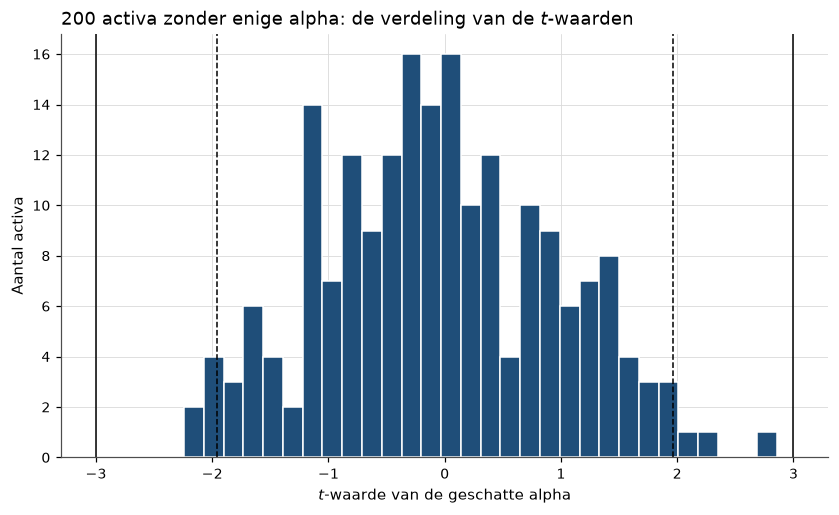

In [5]:
fig, ax = plt.subplots()
ax.hist(t_stats, bins=30, edgecolor="white")
for c, style in [(1.96, "--"), (3.0, "-")]:
    ax.axvline(c, color="black", ls=style, lw=1)
    ax.axvline(-c, color="black", ls=style, lw=1)
ax.set_xlabel("$t$-waarde van de geschatte alpha")
ax.set_ylabel("Aantal activa")
ax.set_title("200 activa zonder enige alpha: de verdeling van de $t$-waarden")
plt.show()

:::{figure} #cel-template-tstats
:label: fig-template-tstats
:width: 90%

De $t$-waarden van 200 activa zonder alpha. De gestreepte lijnen markeren 1,96,
de doorgetrokken lijnen 3,0. Een handvol activa ligt buiten de eerste grens door
toeval alleen; dat is de drempel van Harvey, Liu en Zhu in één figuur.
:::

```{warning}
Herhaal de simulatie nooit met een andere seed tot het getal er mooier uitziet.
Zet de seed één keer bovenaan, rapporteer wat eruit komt, en bespreek de
steekproefruis in de tekst als het afwijkt van de asymptotische waarde.
```

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** Auteur(s), *Titel*, Journal jaar {cite}`Lucas1978`.

**Wat.** Tabel 3, kolom 2 (of: figuur 1, bovenpaneel).

**Data hier.** Kenneth French Data Library, maandelijkse marktfactor 1926-07 tot
heden, via `hap.data.french(...)`.

**Verschil met het origineel.** Het paper gebruikt CRSP tot 19XX; wij de
French-reeks tot heden. De herbalanceringsdatum wijkt af.

**Verwachte afwijking.** Puntschattingen binnen ongeveer 10% van de
gepubliceerde waarden. Het teken en de rangorde van de portefeuilles moeten
identiek zijn; wijkt dát af, dan zit er een fout in de code.
```

Het blok is hoogstens 250 woorden; reekscodes en datumdetails staan in de
codecel. De data komen altijd uit `hap.data`. We laden de reeks en berekenen de
samenvattende statistiek.

In [6]:
# Voorbeeldberekening op gesimuleerde data (in een echte lecture: hap.data.*).
n_years = 100
returns = pd.Series(
    rng.normal(0.08, 0.20, n_years),
    index=pd.period_range("1926", periods=n_years, freq="Y"),
    name="market",
)
se = returns.std(ddof=1) / np.sqrt(n_years)

pd.DataFrame(
    {"origineel": [0.085, 0.20, np.nan],
     "hier": [returns.mean(), returns.std(ddof=1), se]},
    index=["gemiddelde", "standaarddeviatie", "SE gemiddelde"],
).round(4)

,origineel,hier
gemiddelde,0.085,0.0786
standaarddeviatie,0.200,0.1934
SE gemiddelde,NaN,0.0193


**Geslaagd.** Het gemiddelde ligt binnen één standaardfout van de gepubliceerde
waarde en de standaarddeviatie binnen 10%, zoals het replicatieblok voorspelde.
Het oordeel begint altijd met "Geslaagd", "Gedeeltelijk geslaagd" of "Niet
geslaagd" en staat onder een tabel origineel/hier. De figuur laat de cumulatieve
waarde zien.

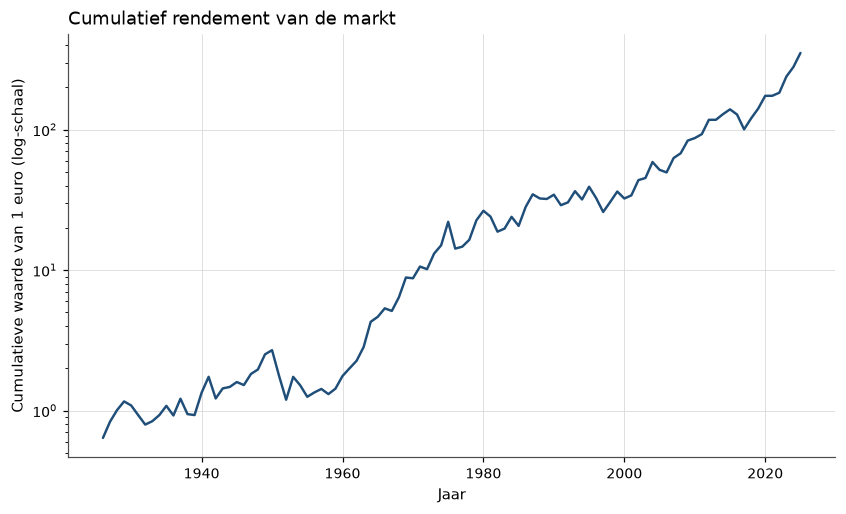

In [7]:
fig, ax = plt.subplots()
ax.plot(returns.index.year, (1 + returns).cumprod(), lw=1.6)
ax.set_yscale("log")
ax.set_xlabel("Jaar")
ax.set_ylabel("Cumulatieve waarde van 1 euro (log-schaal)")
ax.set_title("Cumulatief rendement van de markt")
plt.show()

:::{figure} #cel-template-cumulatief
:label: fig-template-cumulatief
:width: 90%

Cumulatieve waarde van één euro, belegd in de markt. De log-schaal maakt gelijke
procentuele bewegingen even groot; op een lineaire schaal ziet de recente
periode er misleidend dramatisch uit.
:::

## Wat er brak, en wat daarna kwam

Twee tot vier alinea's, elk hoogstens 120 woorden. Benoem expliciet:

1. **Wat het model verklaart.** Wees genereus; het model heeft niet voor niets
   een tijdvak gedomineerd.
2. **Waar het breekt.** Eén concreet, meetbaar feit dat het model niet aankan.
   Liefst het feit dat hierboven is gerepliceerd.
3. **Risico of vergissing?** Geef beide lezingen: de Chicago-lezing (de
   discontovoet varieert) en de Yale-lezing (de prijs zit ernaast). Kies niet
   voor de lezer.
4. **Wat er daarna kwam.** Eén zin die de volgende lecture aankondigt, met een
   cross-ref: zie [](#template).

## Oefeningen

:::{exercise}
:label: ex-template-1

**Instap: het toy-voorbeeld gevarieerd.** Neem het toy-voorbeeld, maar laat de
kans op de goede toestand 0,6 zijn in plaats van 0,5.

1. Bereken $m_g$, $m_s$ en de prijs van de put met de hand.
2. In welke richting verandert de putprijs, en waarom?
:::

:::{solution} ex-template-1
:class: dropdown

**(1)** Obligatie: $0{,}6\,m_g + 0{,}4\,m_s = 0{,}95$. Aandeel:
$0{,}84\,m_g + 0{,}28\,m_s = 0{,}95$. Uit de eerste $m_s = (0{,}95 - 0{,}6\,m_g)/0{,}4$;
invullen geeft $m_g = 0{,}8929$ en $m_s = 1{,}0357$. Put:
$0{,}4 \cdot 1{,}0357 \cdot 0{,}30 = 0{,}1243$.

In [8]:
prob_2 = np.array([0.6, 0.4])
m_2 = np.linalg.solve(payoffs * prob_2, prices)
put_2 = float((prob_2 * m_2) @ np.array([0.00, 0.30]))
pd.Series({"m_goed": m_2[0], "m_slecht": m_2[1], "put": put_2}).round(4)

m_goed      0.6786
m_slecht    1.3571
put         0.1629
dtype: float64

**(2)** De put wordt goedkoper: de slechte toestand is minder waarschijnlijk, dus
de verzekering ertegen is minder waard. Wat dit leert: de prijs van een claim
hangt af van de kans op de toestand én van hoe hard een euro daar nodig is.
:::

:::{exercise}
:label: ex-template-2

**Afleiding en simulatie.** Gebruik [](#eq-template-euler).

1. Leid af dat $R^{f} = 1/\E[m]$.
2. Simuleer 10 000 steekproeven van 100 jaarlijkse rendementen met
   $\mu = 8\%$ en $\sigma = 20\%$. Welke fractie van de steekproeven geeft een
   gemiddeld rendement dat meer dan 4 procentpunt naast de waarheid ligt?
3. Herhaal (2) voor de standaarddeviatie. Vergelijk.
:::

:::{solution} ex-template-2
:class: dropdown

**(1)** Neem $x_{t+1} = 1$ (een risicovrije claim met payoff 1). Dan geeft
[](#eq-template-euler) $p_t = \E_t[m_{t+1}]$, en $R^{f}_{t+1} = 1/p_t = 1/\E_t[m_{t+1}]$.

**(2) en (3)**

In [9]:
n_sim, n_obs, mu, sigma = 10_000, 100, 0.08, 0.20
sims = rng.normal(mu, sigma, size=(n_sim, n_obs))

pd.Series({
    "gemiddelde meer dan 4pp ernaast": np.mean(np.abs(sims.mean(axis=1) - mu) > 0.04),
    "std.dev. meer dan 4pp ernaast": np.mean(np.abs(sims.std(axis=1, ddof=1) - sigma) > 0.04),
}).round(3)

gemiddelde meer dan 4pp ernaast    0.044
std.dev. meer dan 4pp ernaast      0.005
dtype: float64

Vier procentpunt is twee standaardfouten van het gemiddelde
($\sigma/\sqrt{T} = 2$), dus ongeveer 4,5% van de steekproeven valt erbuiten.
Voor de standaarddeviatie is de standaardfout $\sigma/\sqrt{2T} \approx 1{,}4$
procentpunt; vier procentpunt is dan bijna drie standaardfouten en komt in
ongeveer 0,5% van de gevallen voor.

De schaal is het echte verschil. Vier procentpunt naast een gemiddelde van 8% is
een fout van de helft. Vier procentpunt naast een volatiliteit van 20% is een
fout van een vijfde en verandert geen enkele conclusie. Wat dit leert: de
standaardfout van 2% is groot ten opzichte van wat we willen weten, en klein ten
opzichte van wat we goed kunnen meten.
:::

:::{exercise}
:label: ex-template-3

**Uitbreiding van de replicatie.** Herhaal het resultaat uit de replicatie op
een andere steekproefperiode, een andere sortering, of met een robuuste
standaardfout, en interpreteer het verschil.
:::

:::{solution} ex-template-3
:class: dropdown

Uitwerking met code en interpretatie. Sluit af met één zin die begint met
"Wat dit leert:".
:::

<!-- Referenties: MyST plaatst de lijst met geciteerde bronnen automatisch
     onderaan de pagina (kopje "References"). Voeg GEEN eigen `## Referenties`-
     kop en GEEN `{bibliography}`-directive toe; dat geeft een dubbele lijst.
     Citeer in de tekst met {cite}`Key` of [@Key]; de key moet in
     references.bib staan. -->